 Trasformiamo il testo in vettori numerici con TF-IDF, poi classifichiamo con Logistic Regression.
 Effettuiamo la valutazione attraverso Grid Search + Stratified K-Fold (k=5)


In [1]:
import os 
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from joblib import parallel_backend
from tqdm.notebook import tqdm
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed 


# Seed globale — deve essere IDENTICO in tutti i notebook per confronto fair
RANDOM_STATE = 42

# Stile dei plot
sns.set_theme(style="whitegrid", palette="muted")

ModuleNotFoundError: No module named 'tqdm'

In [2]:
import sys
!{sys.executable} -m pip install tqdm tqdm-joblib


   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   -------------------- ------------------- 1/2 [tqdm-joblib]
   ---------------------------------------- 2/2 [tqdm-joblib]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
!pip install tqdm tqdm-joblib

Caricamento del Dataset: andiamo a caricare il dataset pulito.

In [3]:
file_path = r"C:\Users\ruben\Desktop\Progetto_Data-Web\data\github_issues_clean.csv"
df = pd.read_csv(file_path)
print("Dataset caricato con successo!")

#Adattamento colonne
TEXT_COL  = 'text'   # colonna con il testo pulito (title + body concatenati)
LABEL_COL = 'label'        # colonna con la label: bug / feature / question

#Estrazione di X (input) e y (output)
X = df[TEXT_COL].astype(str).values  # Assicuriamoci che siano stringhe
y = df[LABEL_COL].values

#Verifica dei dati
print(f"Campioni totali: {len(X)}")
print(f"\nDistribuzione classi:")
print(pd.Series(y).value_counts())

#Anteprima
print("\nPrime righe caricate:")
print(df.head())



Dataset caricato con successo!
Campioni totali: 59823

Distribuzione classi:
bug         34046
feature     23321
question     2456
Name: count, dtype: int64

Prime righe caricate:
                                                text    label
0  Output file size with -s or -g Was: http://bit...  feature
1  integrate template "special sequences" in help...  feature
2  Add a path option to --keep-video Hey there,\n...  feature
3  add support for picasaweb.google.com video cli...  feature
4  Add debug representation of trait objects ### ...      bug


Plot distribuzione classi: Visualizziamo lo sbilanciamento del dataset

Grafico salvato con successo in: ../figures/class_distribution(2).png


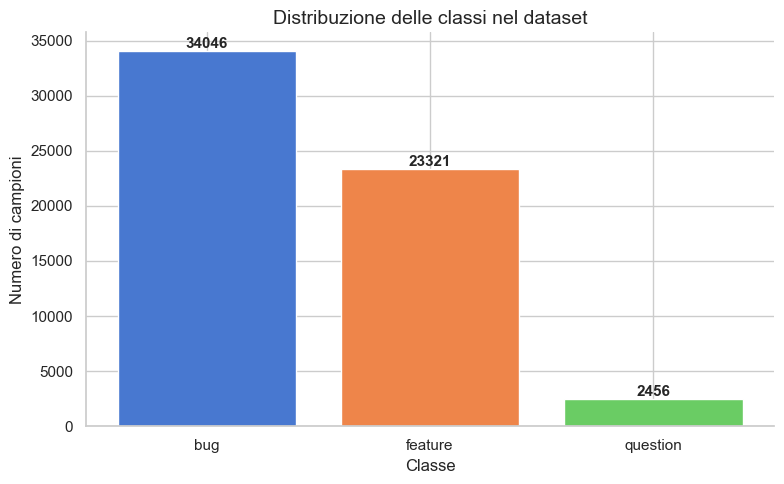

In [4]:
#Calcolo della distribuzione
class_counts = pd.Series(y).value_counts()

#Setup della figura
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette("muted", len(class_counts)))

#Aggiungiamo il conteggio sopra ogni barra
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribuzione delle classi nel dataset', fontsize=14)
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Numero di campioni', fontsize=12)
sns.despine() # Rende il grafico più pulito togliendo i bordi superflui
plt.tight_layout()

#Salviamo nella cartella 
#Verifichiamo se siamo nella cartella corretta del progetto
output_path = '../figures/class_distribution(2).png'

plt.savefig(output_path, dpi=150)
print(f"Grafico salvato con successo in: {output_path}")
plt.show()

Definizione del K-Fold:
StratifiedKFold divide il dataset in 5 fold mantenendo le proporzioni delle classi in ogni fold(fondamentale perchè il nostro è un dataset sbilanciato).

Funzionamento:
Fold 1: [TEST  | train | train | train | train]
Fold 2: [train | TEST  | train | train | train]
Fold 3: [train | train | TEST  | train | train]
Fold 4: [train | train | train | TEST  | train]
Fold 5: [train | train | train | train | TEST ]

Il modello viene allenato e valutato 5 volte.
La metrica finale è la media dei 5 risultati.

In [5]:
cv = StratifiedKFold(
    n_splits=5,               #5 fold
    shuffle=True,             #mescola prima di dividere, evita bias sull'ordine
    random_state=RANDOM_STATE #stesso seed in tutti i notebook
)

Creazione di Pipeline che concatena TfidfVectorizer e LogisticRegression in un unico oggetto.
Importante per evitare il DATA LEAKAGE, ovvero, nella Grid Search, il TF-IDF impara il vocabolario SOLO sul training set di ogni fold, mai sul validation set.
Se applicassimo il TF-IDF prima della Grid Search, il vocabolario
sarebbe contaminato dai dati di validazione.

In [6]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        sublinear_tf=True,
        # usa 1 + log(tf) invece di tf grezzo
        # riduce l'impatto di parole molto frequenti (es. "the", "is")
        min_df=2,
        # ignora termini che appaiono in meno di 2 documenti
        # rimuove typo e termini rarissimi che non generalizzano
        max_df=0.95,
        # ignora termini che appaiono in più del 95% dei documenti
        # rimuove stopwords domain-specific automaticamente
        ngram_range=(1, 2),
        # considera sia singole parole (unigram) che coppie (bigram)
        # es. "null pointer" viene catturato come bigram
        token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
        # considera solo token alfabetici di almeno 2 caratteri
        # filtra numeri, simboli e caratteri singoli
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        # aumentiamo le iterazioni massime per garantire la convergenza
        random_state=RANDOM_STATE
    ))
])
 

Ci assicuriamo che X sia un array di stringhe e y un array di etichette pulito, per evitare che X sia rimasto un oggetto pandas/una lista di liste.

In [12]:
# --- FORZAMENTO LIGHT PER EVITARE MEMORY ERROR ---

# 1. Trasformiamo in liste Python semplici (molto più efficienti per testi lunghi)
X = df[TEXT_COL].astype(str).tolist()
y = df[LABEL_COL].astype(str).tolist()

# 2. Verifica rapida
print(f"Numero di campioni X: {len(X)}")
print(f"Numero di campioni y: {len(y)}")

# 3. Controllo opzionale: vediamo quanto è lungo il testo più lungo
max_len = max(len(s) for s in X)
print(f"Lunghezza massima del testo: {max_len} caratteri")

Numero di campioni X: 59823
Numero di campioni y: 59823
Lunghezza massima del testo: 254267 caratteri


Effettuiamo la Grid Search che prova tutte le combinazioni dei parametri specificati e trova quella che massimizza F1 macro sul k-fold.

Parametri con prefisso clf__ appartengono alla LogisticRegression.

C sarebbe la forza di regolarizzazione:  
 -C piccolo = più regolarizzazione = modello più semplice, meno overfitting;

 -C gande  = meno regolarizzazione = modello più complesso, rischio overfitting class_weight;

 -None = tutti i campioni pesano uguale;

 -Balanced  = le classi rare pesano di più, compensa lo sbilanciamento.

In [ ]:
param_grid = {
    'clf__C':            [0.01, 0.1, 1, 10, 100],
    'clf__solver':       ['lbfgs', 'liblinear'],
    'clf__class_weight': [None, 'balanced']
}
 
grid_search = GridSearchCV(
    estimator=pipeline,    # il pipeline da ottimizzare
    param_grid=param_grid, # combinazioni da esplorare
    cv=cv,                 # StratifiedKFold — divide train/validation da solo
    scoring='f1_macro',    # ottimizziamo su F1 macro (meglio di accuracy con classi sbilanciate)
    n_jobs=1,              # lavora in modo sequenziale (-1 non viene retto)
    verbose=1              # stampa il progresso
)# fit su TUTTO X e y — il k-fold interno gestisce la separazione train/validation
grid_search.fit(X, y)
 
print(f"\nGrid Search completata")
print(f"Migliori parametri:      {grid_search.best_params_}")
print(f"Miglior F1 macro (cv):   {grid_search.best_score_:.4f}")
 
 
 

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\ruben\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ruben\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ruben\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\ruben\AppDa


✅ Grid Search completata
Migliori parametri:      {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__solver': 'lbfgs'}
Miglior F1 macro (cv):   0.7489


Plot risultati Grid Search:

Visualizziamo come varia F1 macro al variare di C utile per capire se il modello è sensibile alla regolarizzazione.

Grafico salvato in: ../figures/gridsearch_performance.png


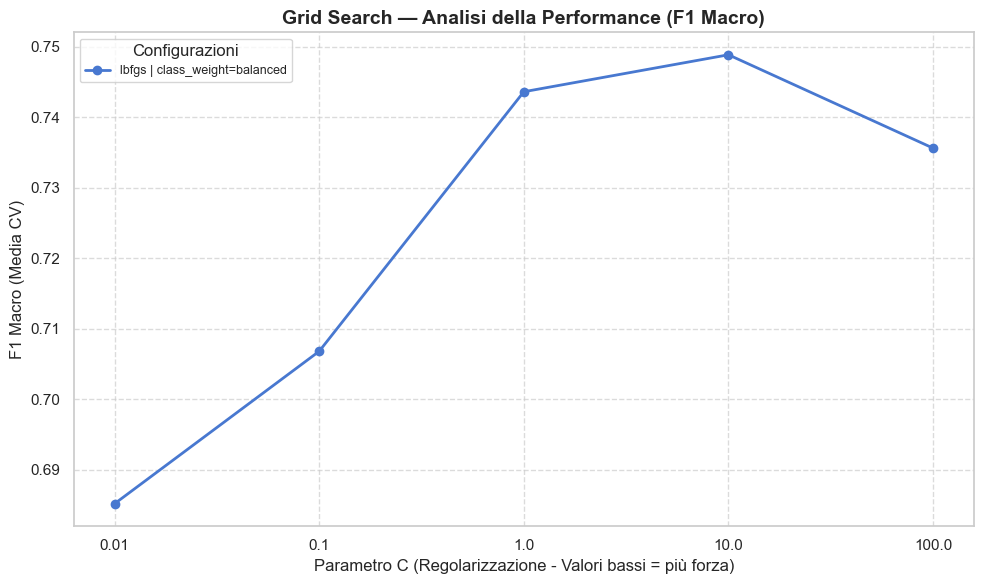

In [14]:
#Estraiamo i risultati della Grid Search in un DataFrame
results_gs = pd.DataFrame(grid_search.cv_results_)

#Setup della figura
fig, ax = plt.subplots(figsize=(10, 6))

#Iteriamo sui parametri per creare le linee del grafico
for solver in ['lbfgs', 'liblinear']:
    for cw in [None, 'balanced']:
        # Creiamo una maschera per filtrare i risultati specifici
        # Nota: usiamo .fillna('None') se necessario per gestire i valori nulli nei parametri
        mask = (
            (results_gs['param_clf__solver'] == solver) & 
            (results_gs['param_clf__class_weight'].apply(lambda x: x == cw))
        )
        
        subset = results_gs[mask].sort_values('param_clf__C')
        
        # Saltiamo il plot se il subset è vuoto o contiene solo NaN (come per liblinear multiclass)
        if subset['mean_test_score'].isna().all():
            continue
            
        label = f"{solver} | class_weight={cw}"
        
        ax.plot(
            subset['param_clf__C'].astype(str), 
            subset['mean_test_score'], 
            marker='o', 
            linewidth=2,
            label=label
        )

# Formiamo il grafico
ax.set_title('Grid Search — Analisi della Performance (F1 Macro)', fontsize=14, fontweight='bold')
ax.set_xlabel('Parametro C (Regolarizzazione - Valori bassi = più forza)', fontsize=12)
ax.set_ylabel('F1 Macro (Media CV)', fontsize=12)
ax.legend(title="Configurazioni", fontsize=9, loc='best')
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

#Salviamo 
output_folder = '../figures'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

plt.savefig(f'{output_folder}/gridsearch_performance.png', dpi=150)
print(f"Grafico salvato in: {output_folder}/gridsearch_performance.png")
plt.show()

Effettuiamo Cross-Validation finale:

Ora che abbiamo i migliori iperparametri, eseguiamo la cross-validationfinale per ottenere le metriche da riportare nel paper.

Perché non usiamo best_score_ dalla Grid Search?
Perchè è un numero ottimistico, calcolato durante la ricerca degli iperparametri.

La cross-validate finale con i parametri fissi dà una stima più onesta.

In [15]:
#Recuperiamo i migliori parametri
best_params = grid_search.best_params_

#Definiamo la pipeline finale con i parametri ottimizzati
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
        ngram_range=(1, 2),
        token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
    )),
    ('clf', LogisticRegression(
        C=best_params['clf__C'],
        solver=best_params['clf__solver'],
        class_weight=best_params['clf__class_weight'],
        max_iter=1000,
        random_state=42
    ))
])

#Eseguiamo la validazione incrociata (usiamo n_jobs=1 per sicurezza RAM)
print("Calcolo delle metriche finali in corso...")
scores = cross_validate(
    final_pipeline,
    X, y, # Usa le liste pulite generate nei passaggi precedenti
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'f1_weighted'],
    return_train_score=False,
    n_jobs=1 
)

#Organizziamo i risultati in un dizionario pulito
results_tfidf = {
    'strategy':      'TF-IDF',
    'accuracy':      round(float(np.mean(scores['test_accuracy'])), 4),
    'f1_macro':      round(float(np.mean(scores['test_f1_macro'])), 4),
    'f1_macro_std':  round(float(np.std(scores['test_f1_macro'])), 4),
    'f1_weighted':   round(float(np.mean(scores['test_f1_weighted'])), 4),
    'best_params':   best_params
}

#Stampa dei risultati
print("\n" + "="*30)
print("RISULTATI FINALI TF-IDF:")
print("="*30)
print(f"Accuracy:    {results_tfidf['accuracy']}")
print(f"F1 Macro:    {results_tfidf['f1_macro']} ± {results_tfidf['f1_macro_std']}")
print(f"F1 Weighted: {results_tfidf['f1_weighted']}")
print("="*30)

Calcolo delle metriche finali in corso...


KeyboardInterrupt: 

CELL 9: Plot F1 per fold ──────────────────────────────────────────────────
isualizziamo F1 macro su ogni fold — serve per verificare che il risultato
sia stabile e non dovuto a un fold particolarmente fortunato.

In [ ]:
fold_f1 = scores['test_f1_macro']
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f'Fold {i+1}' for i in range(len(fold_f1))], fold_f1,
       color=sns.color_palette("muted", len(fold_f1)))
ax.axhline(np.mean(fold_f1), color='red', linestyle='--',
           label=f'Media = {np.mean(fold_f1):.4f}')
ax.set_title('F1 Macro per fold — TF-IDF', fontsize=13)
ax.set_ylabel('F1 Macro')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../results/fold_scores_tfidf.png', dpi=150)
plt.show()
 

 CELL 10: Classification Report ───────────────────────────────────────────
Precision, Recall e F1 per ogni classe (bug / feature / question).
Riallenamo su tutto il dataset per ottenere le predizioni.

In [ ]:
final_pipeline.fit(X, y)
y_pred = final_pipeline.predict(X)
 
print("📋 Classification Report per classe:")
print(classification_report(y, y_pred))
 

CELL 11: Confusion Matrix Mostra quante issue per classe vengono classificate correttamente
 e dove si concentrano gli errori tra le classi.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
 
cm = confusion_matrix(y, y_pred, labels=final_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=final_pipeline.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
 
ax.set_title('Confusion Matrix — TF-IDF + Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig('../results/confusion_matrix_tfidf.png', dpi=150)
plt.show()

 Top feature per classe ──────────────────────────────────────────
Visualizziamo le parole con il peso più alto per ogni classe.
Utile per capire cosa il modello ha imparato e commentarlo nel paper.

In [ ]:
feature_names = final_pipeline.named_steps['tfidf'].get_feature_names_out()
# estrae i nomi di tutti i termini nel vocabolario TF-IDF
 
coef = final_pipeline.named_steps['clf'].coef_
# matrice dei coefficienti: righe = classi, colonne = feature
# un coefficiente alto per una feature significa che quella parola
# è molto indicativa per quella classe
 
classes = final_pipeline.classes_
top_n = 15  # numero di feature da visualizzare per classe
 
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5))
 
for i, (cls, ax) in enumerate(zip(classes, axes)):
    top_indices = np.argsort(coef[i])[-top_n:]
    # prende gli indici delle top_n feature con coefficiente più alto
    top_features = feature_names[top_indices]
    top_weights = coef[i][top_indices]
 
    ax.barh(top_features, top_weights,
            color=sns.color_palette("muted")[i])
    ax.set_title(f'Top {top_n} feature — {cls}', fontsize=12)
    ax.set_xlabel('Coefficiente LR')
 
plt.suptitle('Feature più importanti per classe (TF-IDF)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/top_features_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
 

Salvataggio risultati ────────────────────────────────────────────
 Salviamo le metriche in JSON — il notebook 05_results_comparison.ipynb
caricherà questo file insieme a quelli di SBERT e Prompt Engineering
per costruire la tabella comparativa del paper.

In [ ]:
import os
os.makedirs('../results', exist_ok=True)
 
with open('../results/results_tfidf.json', 'w') as f:
    json.dump(results_tfidf, f, indent=2)
 
print("✅ Risultati salvati in ../results/results_tfidf.json")
print()
print(json.dumps(results_tfidf, indent=2))